In [1]:
import pandas as pd
df_encoded = pd.read_csv('../data/processed/churn_cleaned_encoded.csv')

In [2]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4yr+
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,False,False,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,False,True,False
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,False,False,False
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,False,True,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,False,False,False


In [3]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 35) (1409, 35)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [4]:
#Logistic regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

ROC-AUC: 0.8417861479242552


In [5]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200, 
    class_weight='balanced', 
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409

ROC-AUC: 0.8418675243483426
[[773 262]
 [ 85 289]]


In [6]:
from xgboost import XGBClassifier

# calculate scale_pos_weight for imbalance (XGBoost doesn't have class_weight)
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8384871735255368


In [7]:
import joblib

joblib.dump(log_model, '../models/churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X_train.columns), '../models/feature_columns.pkl')


print("Model ,feature column and scaler saved successfully!")

Model ,feature column and scaler saved successfully!


Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


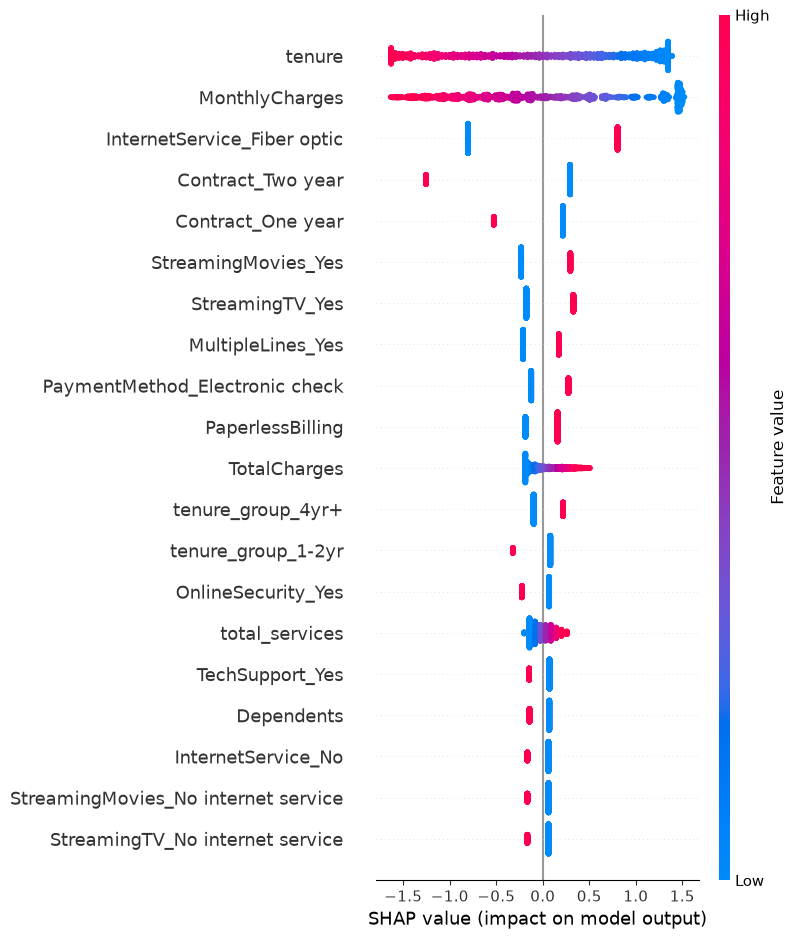

In [8]:
import shap

explainer = shap.LinearExplainer(log_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)

In [9]:
import numpy as np

# Get predictions on test set with probabilities
test_results = X_test.copy()
test_results['actual_churn'] = y_test.values
test_results['churn_probability'] = y_pred_proba  # from logistic regression
test_results['MonthlyCharges'] = X_test['MonthlyCharges'].values

# Define high-risk customers (probability > 0.5, or top 20%)
high_risk_threshold = test_results['churn_probability'].quantile(0.80)  # top 20%
test_results['high_risk'] = test_results['churn_probability'] >= high_risk_threshold

# Business assumptions (idi document చేయాలి README లో)
retention_offer_cost = 200   # ₹ cost per customer for retention offer/discount
avg_customer_lifetime_value = test_results['MonthlyCharges'].mean() * 24  # assume 24 month avg future lifetime

# Revenue at risk among high-risk customers who ACTUALLY churned
high_risk_actual_churners = test_results[(test_results['high_risk']) & (test_results['actual_churn']==1)]
revenue_at_risk = high_risk_actual_churners['MonthlyCharges'].sum() * 24

# Cost of targeting all high-risk customers with retention offers
total_high_risk = test_results['high_risk'].sum()
total_offer_cost = total_high_risk * retention_offer_cost

print(f"High-risk customers identified: {total_high_risk}")
print(f"Actual churners among them: {len(high_risk_actual_churners)}")
print(f"Estimated revenue at risk (if no action): ₹{revenue_at_risk:,.0f}")
print(f"Cost to run retention campaign for all high-risk: ₹{total_offer_cost:,.0f}")
print(f"Potential net savings: ₹{revenue_at_risk - total_offer_cost:,.0f}")

High-risk customers identified: 282
Actual churners among them: 185
Estimated revenue at risk (if no action): ₹349,334
Cost to run retention campaign for all high-risk: ₹56,400
Potential net savings: ₹292,934
